In [ ]:
!pip install -q segmentation-models-pytorch albumentations torchvision

In [22]:
import os, glob, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
import torchvision.transforms as T
import torchvision.models as tvm
import segmentation_models_pytorch as smp
import albumentations as A
from albumentations.pytorch import ToTensorV2

from sklearn.model_selection import KFold, train_test_split
from sklearn.metrics import (
    roc_auc_score, f1_score, recall_score, precision_score,
    accuracy_score, confusion_matrix, ConfusionMatrixDisplay
)
from imblearn.over_sampling import RandomOverSampler

warnings.filterwarnings('ignore')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)

# ── Paths (Kaggle) ──
PATH_BUSI = '/kaggle/input/datasets/aryashah2k/breast-ultrasound-images-dataset/Dataset_BUSI_with_GT'
PATH_USG  = '/kaggle/input/datasets/meganmacri/breast-lesion-usg/BrEaST-Lesions_USG-images_and_masks'


# ── Hyperparams ──
IMG_SIZE       = 256
BATCH_SIZE     = 8
SEG_EPOCHS     = 60
CLS_EPOCHS     = 60
LR_SEG         = 1e-4
LR_CLS         = 1e-3
N_SPLITS       = 5
SEED           = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


Device: cuda


In [24]:
def load_dataset(path, classes=('benign','malignant')):
    """Returns lists of (image_np, mask_np, label) for each class folder."""
    images, masks, labels = [], [], []
    for cls in classes:
        folder = os.path.join(path, cls)
        if not os.path.isdir(folder):
            continue
        img_files = sorted([f for f in glob.glob(os.path.join(folder,'*.png'))
                            if 'mask' not in os.path.basename(f)])
        for img_path in img_files:
            # load image
            img = np.array(Image.open(img_path).convert('L').resize((IMG_SIZE,IMG_SIZE)))
            img = img.astype(np.float32) / 255.0
            # load mask(s) — may be multiple masks per image
            base = img_path.replace('.png','')
            msk_paths = sorted(glob.glob(base + '_mask*.png'))
            if not msk_paths:
                msk_paths = sorted(glob.glob(base + '_mask.png'))
            if not msk_paths:
                continue
            msk = np.zeros((IMG_SIZE, IMG_SIZE), dtype=np.float32)
            for mp in msk_paths:
                m = np.array(Image.open(mp).convert('L').resize((IMG_SIZE,IMG_SIZE)))
                msk = np.clip(msk + m.astype(np.float32)/255.0, 0, 1)
            msk = (msk > 0.5).astype(np.float32)
            images.append(img)
            masks.append(msk)
            labels.append(cls)
    return np.array(images), np.array(masks), np.array(labels)

# load BUSI (benign+malignant only → 697 images)
busi_images, busi_masks, busi_labels = load_dataset(PATH_BUSI)
print('BUSI:', busi_images.shape, Counter(busi_labels))

# load USG
usg_images,  usg_masks,  usg_labels  = load_dataset(PATH_USG)
print('USG: ', usg_images.shape,  Counter(usg_labels))


BUSI: (647, 256, 256) Counter({np.str_('benign'): 437, np.str_('malignant'): 210})
USG:  (252, 256, 256) Counter({np.str_('benign'): 154, np.str_('malignant'): 98})


In [1]:
## Augmentation & PyTorch Dataset

In [25]:
# Geometric augmentation (conservative, preserves lesion morphology)
train_aug = A.Compose([
    A.Rotate(limit=20, p=0.5),
    A.ShiftScaleRotate(shift_limit=0.2, scale_limit=0.2, rotate_limit=0, p=0.5),
    A.HorizontalFlip(p=0.5),
    A.Normalize(mean=0.0, std=1.0),
    ToTensorV2(),
])

val_aug = A.Compose([
    A.Normalize(mean=0.0, std=1.0),
    ToTensorV2(),
])


class BUSDataset(Dataset):
    def __init__(self, images, masks, labels, transform=None, task='seg'):
        self.images = images
        self.masks  = masks
        self.labels = (labels == 'malignant').astype(np.float32)
        self.transform = transform
        self.task = task

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = self.images[idx]                # (H,W) float32
        msk = self.masks[idx]                 # (H,W) float32
        lbl = self.labels[idx]
        img_rgb = np.stack([img]*3, axis=-1)  # (H,W,3) for augmentation
        if self.transform:
            aug = self.transform(image=img_rgb, mask=msk)
            img_t = aug['image']              # (3,H,W)
            msk_t = aug['mask'].unsqueeze(0)  # (1,H,W)
        else:
            img_t = torch.from_numpy(img_rgb.transpose(2,0,1))
            msk_t = torch.from_numpy(msk).unsqueeze(0)
        return img_t, msk_t, torch.tensor(lbl, dtype=torch.float32)


In [ ]:
## Loss functions

In [26]:
class CombinedSegLoss(nn.Module):
    """BCE(0.4) + DiceLoss(0.5) + IoULoss(0.5) — matches paper weights."""
    def __init__(self):
        super().__init__()
        self.bce  = nn.BCEWithLogitsLoss()
        self.dice = smp.losses.DiceLoss(mode='binary', from_logits=True)
        self.iou  = smp.losses.JaccardLoss(mode='binary', from_logits=True)

    def forward(self, pred, target):
        return 0.4*self.bce(pred, target) + 0.5*self.dice(pred, target) + 0.5*self.iou(pred, target)


def iou_metric(pred_bin, target_bin):
    pred_bin   = pred_bin.bool()
    target_bin = target_bin.bool()
    inter = (pred_bin & target_bin).float().sum()
    union = (pred_bin | target_bin).float().sum()
    return (inter / (union + 1e-8)).item()


def dice_metric(pred_bin, target_bin):
    inter = (pred_bin * target_bin).float().sum()
    return (2*inter / (pred_bin.float().sum() + target_bin.float().sum() + 1e-8)).item()


def pixel_acc(pred_bin, target_bin):
    return (pred_bin == target_bin).float().mean().item()


In [ ]:
## Segmentation model factory

Supports: `unet`, `fpn`, `deeplabv3plus` × `resnet34`, `efficientnet-b0`

In [27]:
SEG_CONFIGS = [
    # (arch, encoder, base_channels)  — top configs from Table 1
    ('deeplabv3plus', 'resnet34',       64),
    ('unet',          'resnet34',        32),
    ('deeplabv3plus', 'resnet34',        32),
    ('unet',          'efficientnet-b0', 32),
    ('deeplabv3plus', 'efficientnet-b0', 32),
    ('fpn',           'resnet34',        32),
]


def build_seg_model(arch='deeplabv3plus', encoder='resnet34', base_channels=64):
    kwargs = dict(
        encoder_name=encoder,
        encoder_weights='imagenet',
        in_channels=3,
        classes=1,
    )
    if arch == 'unet':
        model = smp.Unet(**kwargs, decoder_channels=(base_channels*8, base_channels*4,
                                                      base_channels*2, base_channels, base_channels//2))
    elif arch == 'fpn':
        model = smp.FPN(**kwargs, decoder_pyramid_channels=base_channels*4,
                        decoder_segmentation_channels=base_channels)
    elif arch == 'deeplabv3plus':
        model = smp.DeepLabV3Plus(**kwargs, decoder_channels=base_channels*4)
    else:
        raise ValueError(f'Unknown arch: {arch}')
    return model.to(DEVICE)


In [ ]:
## Segmentation training / evaluation helpers

In [28]:
def train_seg_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    for imgs, msks, _ in loader:
        imgs, msks = imgs.to(DEVICE), msks.to(DEVICE)
        optimizer.zero_grad()
        preds = model(imgs)
        loss  = criterion(preds, msks)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)


@torch.no_grad()
def eval_seg(model, loader, criterion):
    model.eval()
    total_loss, ious, dices, accs = 0, [], [], []
    for imgs, msks, _ in loader:
        imgs, msks = imgs.to(DEVICE), msks.to(DEVICE)
        preds = model(imgs)
        loss  = criterion(preds, msks)
        total_loss += loss.item()
        pred_bin = (torch.sigmoid(preds) > 0.5).float()
        ious.append(iou_metric(pred_bin, msks))
        dices.append(dice_metric(pred_bin, msks))
        accs.append(pixel_acc(pred_bin, msks))
    n = len(loader)
    return dict(loss=total_loss/n, iou=np.mean(ious),
                dice=np.mean(dices), acc=np.mean(accs))


def run_seg_kfold(images, masks, labels, arch, encoder, base_ch,
                   n_splits=N_SPLITS, epochs=SEG_EPOCHS):
    """K-fold CV on images/masks. Returns (best_model, val_metrics, test_metrics)."""
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    # 50-15-35 split as in paper: 50% train pool, 35% test
    idx_all = np.arange(len(images))
    train_pool, test_idx = train_test_split(
        idx_all, test_size=0.35, random_state=SEED, stratify=labels)

    criterion = CombinedSegLoss()
    best_model, best_val_dice = None, -1
    fold_metrics = []

    for fold, (tr_idx, val_idx) in enumerate(kf.split(train_pool)):
        print(f'  Seg fold {fold+1}/{n_splits}')
        tr  = train_pool[tr_idx]
        val = train_pool[val_idx]

        tr_ds  = BUSDataset(images[tr],  masks[tr],  labels[tr],  train_aug)
        val_ds = BUSDataset(images[val], masks[val], labels[val], val_aug)
        tr_dl  = DataLoader(tr_ds,  BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
        val_dl = DataLoader(val_ds, BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

        model     = build_seg_model(arch, encoder, base_ch)
        optimizer = optim.Adam(model.parameters(), lr=LR_SEG)
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, factor=0.1, patience=3)
        early_stop_counter = 0
        prev_val_loss = float('inf')

        for ep in range(epochs):
            tr_loss  = train_seg_epoch(model, tr_dl, optimizer, criterion)
            val_info = eval_seg(model, val_dl, criterion)
            scheduler.step(val_info['loss'])
            if val_info['loss'] < prev_val_loss:
                prev_val_loss = val_info['loss']
                early_stop_counter = 0
            else:
                early_stop_counter += 1
            if early_stop_counter >= 10:
                print(f'    Early stop at epoch {ep+1}')
                break

        if val_info['dice'] > best_val_dice:
            best_val_dice = val_info['dice']
            best_model = model
        fold_metrics.append(val_info)

    # evaluate best model on held-out test split
    test_ds = BUSDataset(images[test_idx], masks[test_idx], labels[test_idx], val_aug)
    test_dl = DataLoader(test_ds, BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
    test_info = eval_seg(best_model, test_dl, criterion)

    return best_model, fold_metrics, test_info, test_idx


In [ ]:
## Classification model factory

`MobileNetV3-Small`, `EfficientNet-B0`, `ResNet18`, `ResNet50`, `DenseNet121`

In [29]:
CLS_BACKBONES = [
    ('mobilenet_v3_small', 'MLP', 10, 0.5),   # best per paper
    ('efficientnet_b0',   'Linear', 10, 0.0),
    ('resnet50',          'Linear', 10, 0.0),
    ('densenet121',       'MLP',    10, 0.5),
    ('resnet18',          'MLP',    10, 0.5),
]


def build_cls_model(backbone_name='mobilenet_v3_small', head='MLP',
                    unfreeze_k=10, dropout=0.5):
    # load pretrained
    if backbone_name == 'mobilenet_v3_small':
        base = tvm.mobilenet_v3_small(weights=tvm.MobileNet_V3_Small_Weights.IMAGENET1K_V1)
        feat_dim = base.classifier[0].in_features
        base.classifier = nn.Identity()
    elif backbone_name == 'efficientnet_b0':
        base = tvm.efficientnet_b0(weights=tvm.EfficientNet_B0_Weights.IMAGENET1K_V1)
        feat_dim = base.classifier[1].in_features
        base.classifier = nn.Identity()
    elif backbone_name == 'resnet18':
        base = tvm.resnet18(weights=tvm.ResNet18_Weights.IMAGENET1K_V1)
        feat_dim = base.fc.in_features
        base.fc = nn.Identity()
    elif backbone_name == 'resnet50':
        base = tvm.resnet50(weights=tvm.ResNet50_Weights.IMAGENET1K_V1)
        feat_dim = base.fc.in_features
        base.fc = nn.Identity()
    elif backbone_name == 'densenet121':
        base = tvm.densenet121(weights=tvm.DenseNet121_Weights.IMAGENET1K_V1)
        feat_dim = base.classifier.in_features
        base.classifier = nn.Identity()
    else:
        raise ValueError(backbone_name)

    # freeze all, then unfreeze last k parameter groups
    for p in base.parameters():
        p.requires_grad = False
    params = list(base.parameters())
    for p in params[-unfreeze_k:]:
        p.requires_grad = True

    # build head
    if head == 'Linear':
        clf_head = nn.Linear(feat_dim, 1)
    else:  # MLP (128,64)
        clf_head = nn.Sequential(
            nn.Linear(feat_dim, 128), nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 64), nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1)
        )

    class ClsModel(nn.Module):
        def __init__(self, backbone, head):
            super().__init__()
            self.backbone = backbone
            self.head     = head
        def forward(self, x):
            return self.head(self.backbone(x))

    return ClsModel(base, clf_head).to(DEVICE)


In [ ]:
## ROI cropping (stage 1 → stage 2)

In [30]:
def crop_roi(img_np, mask_np, pad=10):
    """Crop image to bounding box of predicted/GT mask. Returns 256×256 crop."""
    rows = np.any(mask_np > 0.5, axis=1)
    cols = np.any(mask_np > 0.5, axis=0)
    if not rows.any():
        return img_np  # no mask — return original
    r0, r1 = np.where(rows)[0][[0, -1]]
    c0, c1 = np.where(cols)[0][[0, -1]]
    r0, c0 = max(0, r0-pad), max(0, c0-pad)
    r1, c1 = min(img_np.shape[0]-1, r1+pad), min(img_np.shape[1]-1, c1+pad)
    crop = img_np[r0:r1+1, c0:c1+1]
    crop_pil = Image.fromarray((crop*255).astype(np.uint8)).resize((IMG_SIZE, IMG_SIZE))
    return np.array(crop_pil).astype(np.float32) / 255.0


@torch.no_grad()
def predict_and_crop(seg_model, images, masks, labels):
    """Run segmentation model, crop ROIs, return (roi_images, labels)."""
    ds = BUSDataset(images, masks, labels, val_aug)
    dl = DataLoader(ds, BATCH_SIZE, shuffle=False, num_workers=2)
    seg_model.eval()
    cropped = []
    for i, (imgs_t, _, _) in enumerate(dl):
        preds = torch.sigmoid(seg_model(imgs_t.to(DEVICE))).cpu().numpy()  # (B,1,H,W)
        for j in range(len(preds)):
            idx  = i * BATCH_SIZE + j
            pred_mask = preds[j, 0]           # (H,W)
            roi = crop_roi(images[idx], pred_mask)
            cropped.append(roi)
    return np.array(cropped), labels


In [ ]:
## Classification training / evaluation helpers

In [32]:
class ROIDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = (np.array(labels) == 'malignant').astype(np.float32)
        self.transform = transform

    def __len__(self): return len(self.images)

    def __getitem__(self, idx):
        img = self.images[idx]
        img_rgb = np.stack([img]*3, axis=-1)
        if self.transform:
            aug = self.transform(image=img_rgb, mask=np.zeros_like(img))
            img_t = aug['image']
        else:
            img_t = torch.from_numpy(img_rgb.transpose(2,0,1))
        return img_t, torch.tensor(self.labels[idx])


def train_cls_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    for imgs, lbls in loader:
        imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE).unsqueeze(1)
        optimizer.zero_grad()
        out  = model(imgs)
        loss = criterion(out, lbls)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)


@torch.no_grad()
def eval_cls(model, loader):
    model.eval()
    all_preds, all_probs, all_gt = [], [], []
    for imgs, lbls in loader:
        imgs = imgs.to(DEVICE)
        probs = torch.sigmoid(model(imgs)).cpu().squeeze(1).numpy()
        preds = (probs > 0.5).astype(int)
        all_probs.extend(probs)
        all_preds.extend(preds)
        all_gt.extend(lbls.numpy())
    all_gt    = np.array(all_gt,    dtype=int)
    all_preds = np.array(all_preds, dtype=int)
    all_probs = np.array(all_probs)
    return dict(
        acc  = accuracy_score(all_gt, all_preds),
        prec = precision_score(all_gt, all_preds, zero_division=0),
        rec  = recall_score(all_gt, all_preds, zero_division=0),
        f1   = f1_score(all_gt, all_preds, zero_division=0),
        auc  = roc_auc_score(all_gt, all_probs)
    )


def run_cls_kfold(roi_images, labels, backbone, head, unfreeze_k, dropout,
                  n_splits=N_SPLITS, epochs=CLS_EPOCHS):
    # oversample minority class in training
    ros = RandomOverSampler(random_state=SEED)
    idx = np.arange(len(roi_images))
    lbl_bin = (labels == 'malignant').astype(int)
    idx_bal, lbl_bal_bin = ros.fit_resample(idx.reshape(-1,1), lbl_bin)
    idx_bal = idx_bal.flatten()
    lbl_bal = np.where(lbl_bal_bin, 'malignant', 'benign')
    imgs_bal = roi_images[idx_bal]

    X_temp, X_test, y_temp, y_test = train_test_split(
        imgs_bal, lbl_bal, test_size=0.2, random_state=SEED, stratify=lbl_bal)

    kf = KFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    criterion = nn.BCEWithLogitsLoss()
    best_model, best_val_f1 = None, -1
    fold_metrics = []

    for fold, (tr_idx, val_idx) in enumerate(kf.split(X_temp)):
        print(f'  Cls fold {fold+1}/{n_splits}')
        tr_ds  = ROIDataset(X_temp[tr_idx],  y_temp[tr_idx],  train_aug)
        val_ds = ROIDataset(X_temp[val_idx], y_temp[val_idx], val_aug)
        tr_dl  = DataLoader(tr_ds,  BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
        val_dl = DataLoader(val_ds, BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

        model     = build_cls_model(backbone, head, unfreeze_k, dropout)
        optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=LR_CLS)
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.1, patience=3)
        early_stop_counter, prev_loss = 0, float('inf')

        for ep in range(epochs):
            tr_loss  = train_cls_epoch(model, tr_dl, optimizer, criterion)
            val_info = eval_cls(model, val_dl)
            scheduler.step(1 - val_info['f1'])
            val_loss_proxy = 1 - val_info['f1']
            if val_loss_proxy < prev_loss:
                prev_loss = val_loss_proxy
                early_stop_counter = 0
            else:
                early_stop_counter += 1
            if early_stop_counter >= 10:
                break

        if val_info['f1'] > best_val_f1:
            best_val_f1 = val_info['f1']
            best_model  = model
        fold_metrics.append(val_info)

    test_ds = ROIDataset(X_test, y_test, val_aug)
    test_dl = DataLoader(test_ds, BATCH_SIZE, shuffle=False, num_workers=2)
    test_info = eval_cls(best_model, test_dl)

    return best_model, fold_metrics, test_info


In [ ]:
---
## Scenario A — Train / Val / Test on BUSI


In [33]:
print('=== SCENARIO A: BUSI only ===')

# ── Segmentation: sweep architectures ──
seg_results_A = []
for arch, encoder, base_ch in SEG_CONFIGS:
    print(f'\n--- Seg: {arch} / {encoder} / ch={base_ch} ---')
    best_seg, fold_m, test_m, test_idx_A = run_seg_kfold(
        busi_images, busi_masks, busi_labels, arch, encoder, base_ch)
    seg_results_A.append(dict(arch=arch, encoder=encoder, base_ch=base_ch,
                              **test_m))
    print(f'  Test → IoU={test_m["iou"]:.3f}  Dice={test_m["dice"]:.3f}  Acc={test_m["acc"]:.3f}')

seg_df_A = pd.DataFrame(seg_results_A).sort_values('dice', ascending=False)
print('\nSegmentation results (Scenario A):')
print(seg_df_A.to_string(index=False))


=== SCENARIO A: BUSI only ===

--- Seg: deeplabv3plus / resnet34 / ch=64 ---
  Seg fold 1/5


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

    Early stop at epoch 34
  Seg fold 2/5
    Early stop at epoch 33
  Seg fold 3/5
    Early stop at epoch 35
  Seg fold 4/5
    Early stop at epoch 25
  Seg fold 5/5
    Early stop at epoch 41
  Test → IoU=0.635  Dice=0.766  Acc=0.958

--- Seg: unet / resnet34 / ch=32 ---
  Seg fold 1/5
    Early stop at epoch 26
  Seg fold 2/5
    Early stop at epoch 35
  Seg fold 3/5
    Early stop at epoch 32
  Seg fold 4/5
    Early stop at epoch 38
  Seg fold 5/5
    Early stop at epoch 39
  Test → IoU=0.647  Dice=0.775  Acc=0.955

--- Seg: deeplabv3plus / resnet34 / ch=32 ---
  Seg fold 1/5
    Early stop at epoch 41
  Seg fold 2/5
    Early stop at epoch 34
  Seg fold 3/5
    Early stop at epoch 35
  Seg fold 4/5
    Early stop at epoch 52
  Seg fold 5/5
    Early stop at epoch 26
  Test → IoU=0.653  Dice=0.778  Acc=0.958

--- Seg: unet / efficientnet-b0 / ch=32 ---
  Seg fold 1/5


config.json:   0%|          | 0.00/106 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

    Early stop at epoch 46
  Seg fold 2/5
    Early stop at epoch 11
  Seg fold 3/5
    Early stop at epoch 43
  Seg fold 4/5
    Early stop at epoch 45
  Seg fold 5/5
    Early stop at epoch 37
  Test → IoU=0.635  Dice=0.768  Acc=0.951

--- Seg: deeplabv3plus / efficientnet-b0 / ch=32 ---
  Seg fold 1/5
  Seg fold 2/5
  Seg fold 3/5
  Seg fold 4/5
  Seg fold 5/5
    Early stop at epoch 51
  Test → IoU=0.631  Dice=0.765  Acc=0.954

--- Seg: fpn / resnet34 / ch=32 ---
  Seg fold 1/5
    Early stop at epoch 44
  Seg fold 2/5
  Seg fold 3/5
    Early stop at epoch 32
  Seg fold 4/5
    Early stop at epoch 41
  Seg fold 5/5
    Early stop at epoch 46
  Test → IoU=0.675  Dice=0.799  Acc=0.962

Segmentation results (Scenario A):
         arch         encoder  base_ch     loss      iou     dice      acc
          fpn        resnet34       32 0.349050 0.675156 0.798572 0.961641
deeplabv3plus        resnet34       32 0.375438 0.652872 0.778184 0.958201
         unet        resnet34       32 0.3

In [34]:
# ── Pick best seg model (DeepLabV3+ / ResNet34 / ch=64) and crop ROIs ──
best_seg_arch_A  = seg_df_A.iloc[0]['arch']
best_seg_enc_A   = seg_df_A.iloc[0]['encoder']
best_seg_ch_A    = int(seg_df_A.iloc[0]['base_ch'])
print(f'Best seg config A: {best_seg_arch_A}/{best_seg_enc_A}/ch={best_seg_ch_A}')

# Re-train best config to obtain best_seg_model_A
best_seg_model_A, _, seg_test_A, test_idx_A = run_seg_kfold(
    busi_images, busi_masks, busi_labels,
    best_seg_arch_A, best_seg_enc_A, best_seg_ch_A)

# Crop ROIs for classification stage
roi_images_A, roi_labels_A = predict_and_crop(
    best_seg_model_A, busi_images, busi_masks, busi_labels)
print(f'ROIs shape: {roi_images_A.shape}')


Best seg config A: fpn/resnet34/ch=32
  Seg fold 1/5
    Early stop at epoch 32
  Seg fold 2/5
    Early stop at epoch 38
  Seg fold 3/5
    Early stop at epoch 41
  Seg fold 4/5
    Early stop at epoch 41
  Seg fold 5/5
    Early stop at epoch 19
ROIs shape: (647, 256, 256)


In [35]:
# ── Classification: sweep backbones ──
cls_results_A = []
for bb, head, uk, dr in CLS_BACKBONES:
    print(f'\n--- Cls: {bb} / head={head} / unfreeze={uk} / drop={dr} ---')
    best_cls, fold_m_cls, test_cls = run_cls_kfold(
        roi_images_A, roi_labels_A, bb, head, uk, dr)
    cls_results_A.append(dict(backbone=bb, head=head, unfreeze_k=uk,
                              dropout=dr, **test_cls))
    print(f'  Test → AUC={test_cls["auc"]:.3f}  F1={test_cls["f1"]:.3f}')

cls_df_A = pd.DataFrame(cls_results_A).sort_values('auc', ascending=False)
print('\nClassification results (Scenario A):')
print(cls_df_A.to_string(index=False))



--- Cls: mobilenet_v3_small / head=MLP / unfreeze=10 / drop=0.5 ---
  Cls fold 1/5
Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 93.9MB/s]


  Cls fold 2/5
  Cls fold 3/5
  Cls fold 4/5
  Cls fold 5/5
  Test → AUC=0.908  F1=0.817

--- Cls: efficientnet_b0 / head=Linear / unfreeze=10 / drop=0.0 ---
  Cls fold 1/5
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 121MB/s] 


  Cls fold 2/5
  Cls fold 3/5
  Cls fold 4/5
  Cls fold 5/5
  Test → AUC=0.978  F1=0.895

--- Cls: resnet50 / head=Linear / unfreeze=10 / drop=0.0 ---
  Cls fold 1/5
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


...

  Cls fold 2/5
  Cls fold 3/5
  Cls fold 4/5
  Cls fold 5/5
  Test → AUC=0.962  F1=0.891

--- Cls: densenet121 / head=MLP / unfreeze=10 / drop=0.5 ---
  Cls fold 1/5
Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 153MB/s] 


  Cls fold 2/5
  Cls fold 3/5
  Cls fold 4/5
  Cls fold 5/5
  Test → AUC=0.971  F1=0.896

--- Cls: resnet18 / head=MLP / unfreeze=10 / drop=0.5 ---
  Cls fold 1/5
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 182MB/s] 


  Cls fold 2/5
  Cls fold 3/5
  Cls fold 4/5
  Cls fold 5/5
  Test → AUC=0.979  F1=0.908

Classification results (Scenario A):
          backbone   head  unfreeze_k  dropout      acc     prec      rec       f1      auc
          resnet18    MLP          10      0.5 0.902857 0.857143 0.965517 0.908108 0.978579
   efficientnet_b0 Linear          10      0.0 0.891429 0.861702 0.931034 0.895028 0.977795
       densenet121    MLP          10      0.5 0.891429 0.854167 0.942529 0.896175 0.971134
          resnet50 Linear          10      0.0 0.885714 0.845361 0.942529 0.891304 0.962252
mobilenet_v3_small    MLP          10      0.5 0.805714 0.767677 0.873563 0.817204 0.907785


In [ ]:
---
## Scenario B — Train / Val / Test on BUSI + Breast-Lesions-USG


In [36]:
print('=== SCENARIO B: BUSI + USG combined ===')

# Merge datasets
all_images = np.concatenate([busi_images, usg_images], axis=0)
all_masks  = np.concatenate([busi_masks,  usg_masks],  axis=0)
all_labels = np.concatenate([busi_labels, usg_labels], axis=0)
print(f'Combined: {all_images.shape}  {Counter(all_labels)}')

best_seg_model_B, _, seg_test_B, _ = run_seg_kfold(
    all_images, all_masks, all_labels,
    best_seg_arch_A, best_seg_enc_A, best_seg_ch_A)
print('Seg test B:', seg_test_B)

roi_images_B, roi_labels_B = predict_and_crop(
    best_seg_model_B, all_images, all_masks, all_labels)

# best classifier from A
best_bb_B  = cls_df_A.iloc[0]['backbone']
best_hd_B  = cls_df_A.iloc[0]['head']
best_uk_B  = int(cls_df_A.iloc[0]['unfreeze_k'])
best_dr_B  = float(cls_df_A.iloc[0]['dropout'])
_, _, cls_test_B = run_cls_kfold(
    roi_images_B, roi_labels_B, best_bb_B, best_hd_B, best_uk_B, best_dr_B)
print('Cls test B:', cls_test_B)


=== SCENARIO B: BUSI + USG combined ===
Combined: (899, 256, 256)  Counter({np.str_('benign'): 591, np.str_('malignant'): 308})
  Seg fold 1/5
    Early stop at epoch 46
  Seg fold 2/5
    Early stop at epoch 36
  Seg fold 3/5
    Early stop at epoch 40
  Seg fold 4/5
    Early stop at epoch 32
  Seg fold 5/5
    Early stop at epoch 39
Seg test B: {'loss': 0.4038950901478529, 'iou': np.float64(0.6331598989665508), 'dice': np.float64(0.7625221721827984), 'acc': np.float64(0.9598245948553086)}
  Cls fold 1/5
  Cls fold 2/5
  Cls fold 3/5
  Cls fold 4/5
  Cls fold 5/5
Cls test B: {'acc': 0.8987341772151899, 'prec': 0.8507462686567164, 'rec': 0.9661016949152542, 'f1': 0.9047619047619048, 'auc': np.float64(0.9510753453923942)}


In [ ]:
---
## Scenario C — Train on BUSI, Test on Breast-Lesions-USG


In [38]:
print('=== SCENARIO C: Train BUSI → Test USG ===')

# Segmentation: re-use best model trained on BUSI (best_seg_model_A)
seg_ds_C  = BUSDataset(usg_images, usg_masks, usg_labels, val_aug)
seg_dl_C  = DataLoader(seg_ds_C, BATCH_SIZE, shuffle=False, num_workers=2)
criterion_seg = CombinedSegLoss()
seg_test_C = eval_seg(best_seg_model_A, seg_dl_C, criterion_seg)
print('Seg test C (BUSI model → USG):', seg_test_C)

# Crop ROIs of USG using BUSI-trained seg model
roi_images_C, roi_labels_C = predict_and_crop(
    best_seg_model_A, usg_images, usg_masks, usg_labels)

# Classification: re-use best cls model from A
test_ds_C = ROIDataset(roi_images_C, roi_labels_C, val_aug)
test_dl_C = DataLoader(test_ds_C, BATCH_SIZE, shuffle=False, num_workers=2)
# obtain best_cls_model_A from previous run
# (run again to get the object if needed)
best_bb_A  = cls_df_A.iloc[0]['backbone']
best_hd_A  = cls_df_A.iloc[0]['head']
best_uk_A  = int(cls_df_A.iloc[0]['unfreeze_k'])
best_dr_A  = float(cls_df_A.iloc[0]['dropout'])
best_cls_model_A, _, _ = run_cls_kfold(
    roi_images_A, roi_labels_A, best_bb_A, best_hd_A, best_uk_A, best_dr_A)
cls_test_C = eval_cls(best_cls_model_A, test_dl_C)
print('Cls test C (BUSI model → USG):', cls_test_C)


=== SCENARIO C: Train BUSI → Test USG ===
Seg test C (BUSI model → USG): {'loss': 0.5122056808322668, 'iou': np.float64(0.5577385467477143), 'dice': np.float64(0.7044820263981819), 'acc': np.float64(0.9606970548629761)}
  Cls fold 1/5
  Cls fold 2/5
  Cls fold 3/5
  Cls fold 4/5
  Cls fold 5/5
Cls test C (BUSI model → USG): {'acc': 0.7579365079365079, 'prec': 0.7283950617283951, 'rec': 0.6020408163265306, 'f1': 0.659217877094972, 'auc': np.float64(0.7831963954412934)}


In [ ]:
## Summary table (Table 3 equivalent)

In [40]:
rows = [
    # Our Approach
    dict(Method='Our Approach', Scenario='A',
         Seg_Acc=seg_test_A['acc'], IoU=seg_test_A['iou'], Dice=seg_test_A['dice'],
         Cls_Acc=cls_results_A[0]['acc'], Prec=cls_results_A[0]['prec'],
         Rec=cls_results_A[0]['rec'],  F1=cls_results_A[0]['f1'],
         AUC=cls_results_A[0]['auc']),
    dict(Method='Our Approach', Scenario='B',
         Seg_Acc=seg_test_B['acc'], IoU=seg_test_B['iou'], Dice=seg_test_B['dice'],
         Cls_Acc=cls_test_B['acc'], Prec=cls_test_B['prec'],
         Rec=cls_test_B['rec'],  F1=cls_test_B['f1'], AUC=cls_test_B['auc']),
    dict(Method='Our Approach', Scenario='C',
         Seg_Acc=seg_test_C['acc'], IoU=seg_test_C['iou'], Dice=seg_test_C['dice'],
         Cls_Acc=cls_test_C['acc'], Prec=cls_test_C['prec'],
         Rec=cls_test_C['rec'],  F1=cls_test_C['f1'], AUC=cls_test_C['auc']),
]

summary_df = pd.DataFrame(rows)
print(summary_df.round(3).to_string(index=False))


      Method Scenario  Seg_Acc   IoU  Dice  Cls_Acc  Prec   Rec    F1   AUC
Our Approach        A    0.957 0.651 0.783    0.806 0.768 0.874 0.817 0.908
Our Approach        B    0.960 0.633 0.763    0.899 0.851 0.966 0.905 0.951
Our Approach        C    0.961 0.558 0.704    0.758 0.728 0.602 0.659 0.783


In [ ]:
## Visualisations

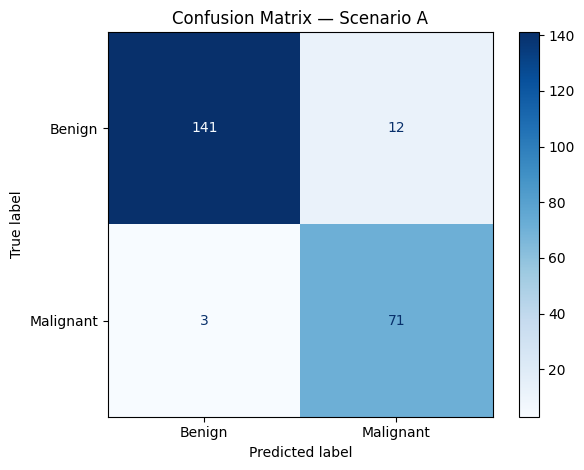

In [41]:
# Confusion matrix — Scenario A
test_ds_vis = ROIDataset(roi_images_A[test_idx_A], roi_labels_A[test_idx_A], val_aug)
test_dl_vis = DataLoader(test_ds_vis, BATCH_SIZE, shuffle=False, num_workers=2)
all_preds_vis, all_gt_vis, all_probs_vis = [], [], []
with torch.no_grad():
    for imgs, lbls in test_dl_vis:
        probs = torch.sigmoid(best_cls_model_A(imgs.to(DEVICE))).cpu().squeeze(1).numpy()
        all_probs_vis.extend(probs)
        all_preds_vis.extend((probs > 0.5).astype(int))
        all_gt_vis.extend(lbls.numpy().astype(int))

cm = confusion_matrix(all_gt_vis, all_preds_vis)
disp = ConfusionMatrixDisplay(cm, display_labels=['Benign','Malignant'])
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix — Scenario A')
plt.tight_layout()
plt.show()


In [ ]:
# Segmentation examples — best and worst cases (Scenario A)
seg_ds_vis = BUSDataset(busi_images, busi_masks, busi_labels, val_aug)
seg_dl_vis = DataLoader(seg_ds_vis, 1, shuffle=False, num_workers=2)
best_seg_model_A.eval()

results = []
with torch.no_grad():
    for i, (img_t, msk_t, _) in enumerate(seg_dl_vis):
        pred = torch.sigmoid(best_seg_model_A(img_t.to(DEVICE))).cpu().numpy()[0,0]
        pred_bin = (pred > 0.5).astype(float)
        msk_np   = msk_t.numpy()[0,0]
        d = dice_metric(torch.from_numpy(pred_bin), torch.from_numpy(msk_np))
        results.append((d, i, img_t[0].numpy(), msk_np, pred))

results.sort(key=lambda x: x[0])
worst2 = results[:2]
best2  = results[-2:]

fig, axes = plt.subplots(4, 3, figsize=(12, 16))
for row_i, (d, idx, img_t, msk_np, pred) in enumerate(best2 + worst2):
    img_show = img_t.transpose(1,2,0)[:,:,0]
    axes[row_i,0].imshow(img_show, cmap='gray')
    axes[row_i,0].set_title('Raw')
    axes[row_i,0].axis('off')
    axes[row_i,1].imshow(msk_np, cmap='gray')
    axes[row_i,1].set_title('GT')
    axes[row_i,1].axis('off')
    axes[row_i,2].imshow(img_show, cmap='gray')
    axes[row_i,2].imshow(pred, cmap='Reds', alpha=0.5)
    axes[row_i,2].set_title(f'Pred  Dice={d:.3f}')
    axes[row_i,2].axis('off')

plt.suptitle('Top: best cases | Bottom: worst cases', y=1.01)
plt.tight_layout()
plt.show()
